<!-- Introduction To Neural Networks -->

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = {
    'feature1': [0.1, 0.2, 0.3, 0.4, 0.5],
    'feature2': [0.5, 0.4, 0.3, 0.2, 0.1],
    'label': [0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
X = df[['feature1', 'feature2']].values
y = df['label'].values

In [3]:
model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss='binary_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [5]:
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6000 - loss: 0.7055   
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.7035     
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.7016
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.7001     
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6980     
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.6963 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.6940 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6926     
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6898 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.6881    
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.6856 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 

In [6]:
test_data = np.array([[0.2, 0.4]])
prediction = model.predict(test_data)
predicted_label = (prediction > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


Stochastic Gradient Descent (SGD)

In [7]:
import numpy as np

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [8]:
def sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1):
    m = len(X)
    theta = np.random.randn(2, 1)

    X_bias = np.c_[np.ones((m, 1)), X]

    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradients = 2 / batch_size * \
                X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta -= learning_rate * gradients

        predictions = X_bias.dot(theta)
        cost = np.mean((predictions - y) ** 2)
        cost_history.append(cost)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Cost: {cost}")

    return theta, cost_history

In [9]:
theta_final, cost_history = sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1)

Epoch 0, Cost: 1.581821686856939
Epoch 100, Cost: 1.5664692700155733
Epoch 200, Cost: 1.4445422391173144
Epoch 300, Cost: 1.7037674963102662
Epoch 400, Cost: 0.9101999515899212
Epoch 500, Cost: 0.8184497904316664
Epoch 600, Cost: 0.8352333304446237
Epoch 700, Cost: 0.8542729530055074
Epoch 800, Cost: 1.0508310318687628
Epoch 900, Cost: 0.8261971232182218


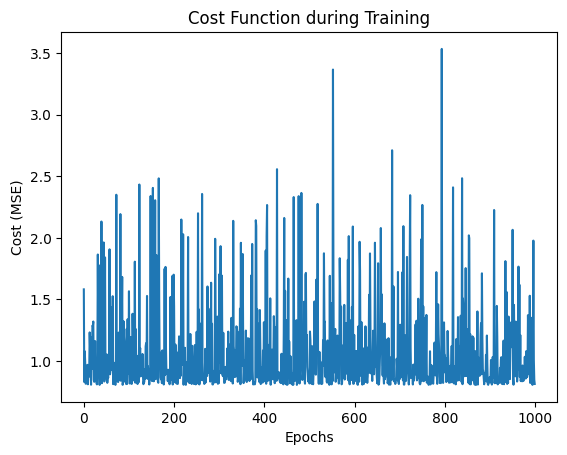

In [10]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function during Training')
plt.show()

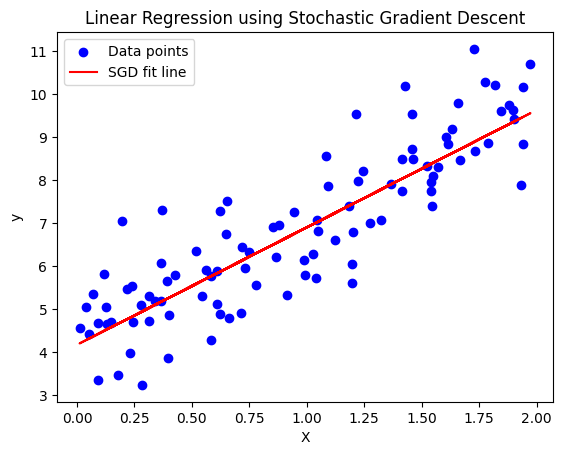

In [11]:
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(
    theta_final), color='red', label='SGD fit line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression using Stochastic Gradient Descent')
plt.legend()
plt.show()

In [12]:
print(f"Final parameters: {theta_final}")

Final parameters: [[4.17209292]
 [2.72564644]]


Mini-Batch Gradient Descent with Python

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
mean = np.array([5.0, 6.0])
cov = np.array([[1.0, 0.95], [0.95, 1.2]])
data = np.random.multivariate_normal(mean, cov, 8000)

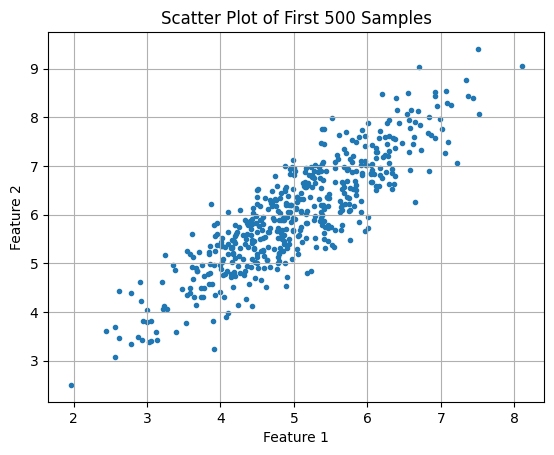

In [15]:
plt.scatter(data[:500, 0], data[:500, 1], marker='.')
plt.title("Scatter Plot of First 500 Samples")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [16]:
data = np.hstack((np.ones((data.shape[0], 1)), data))  

split_factor = 0.90
split = int(split_factor * data.shape[0])

X_train = data[:split, :-1]
y_train = data[:split, -1].reshape((-1, 1))
X_test = data[split:, :-1]
y_test = data[split:, -1].reshape((-1, 1))

In [17]:
print("Number of examples in training set = %d" % X_train.shape[0])
print("Number of examples in testing set = %d" % X_test.shape[0])

Number of examples in training set = 7200
Number of examples in testing set = 800


In [18]:
def hypothesis(X, theta):
    return np.dot(X, theta)

def gradient(X, y, theta):
    h = hypothesis(X, theta)
    grad = np.dot(X.T, (h - y))
    return grad

def cost(X, y, theta):
    h = hypothesis(X, theta)
    J = np.dot((h - y).T, (h - y)) / 2
    return J[0]

In [19]:
def create_mini_batches(X, y, batch_size):
    mini_batches = []
    data = np.hstack((X, y))
    np.random.shuffle(data)
    n_minibatches = data.shape[0] // batch_size
    for i in range(n_minibatches + 1):
        mini_batch = data[i * batch_size:(i + 1) * batch_size, :]
        X_mini = mini_batch[:, :-1]
        Y_mini = mini_batch[:, -1].reshape((-1, 1))
        mini_batches.append((X_mini, Y_mini))
    if data.shape[0] % batch_size != 0:
        mini_batch = data[i * batch_size:]
        X_mini = mini_batch[:, :-1]
        Y_mini = mini_batch[:, -1].reshape((-1, 1))
        mini_batches.append((X_mini, Y_mini))
    return mini_batches

In [20]:
def gradientDescent(X, y, learning_rate=0.001, batch_size=32):
    theta = np.zeros((X.shape[1], 1))
    error_list = []
    max_iters = 3

    for itr in range(max_iters):
        mini_batches = create_mini_batches(X, y, batch_size)
        for X_mini, y_mini in mini_batches:
            theta = theta - learning_rate * gradient(X_mini, y_mini, theta)
            error_list.append(cost(X_mini, y_mini, theta))

    return theta, error_list

Bias =  [0.77800579]
Coefficients =  [[1.01981663]]


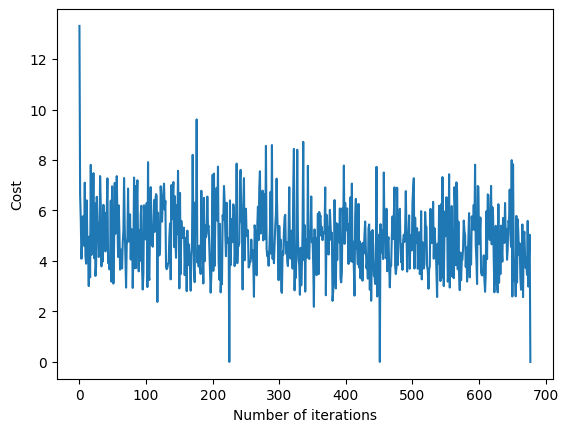

In [21]:
theta, error_list = gradientDescent(X_train, y_train)
print("Bias = ", theta[0])
print("Coefficients = ", theta[1:])

plt.plot(error_list)
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.show()

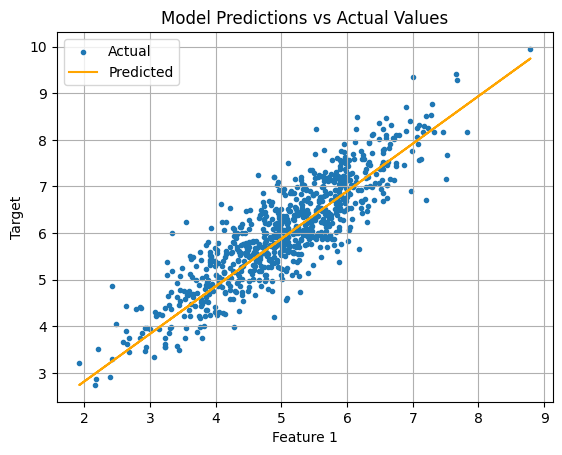

Mean Absolute Error = 0.44497349664618346


In [22]:
y_pred = hypothesis(X_test, theta)

plt.scatter(X_test[:, 1], y_test, marker='.', label='Actual')
plt.plot(X_test[:, 1], y_pred, color='orange', label='Predicted')
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.title("Model Predictions vs Actual Values")
plt.legend()
plt.grid(True)
plt.show()

error = np.sum(np.abs(y_test - y_pred)) / y_test.shape[0]
print("Mean Absolute Error =", error)

Momentum-based Gradient Optimizer - ML

In [23]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8757 - loss: 0.4699
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9212 - loss: 0.2821
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9319 - loss: 0.2447
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9385 - loss: 0.2207
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9439 - loss: 0.2030


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


model = SimpleModel()

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adagrad(model.parameters(), lr=0.01)

for epoch in range(5):
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete")

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.52MB/s]


Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete


RMSProp Optimizer

In [25]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [26]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [27]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [29]:
history = model.fit(x_train, y_train, epochs=10,
                    batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9232 - loss: 0.2610 - val_accuracy: 0.9556 - val_loss: 0.1439
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9665 - loss: 0.1142 - val_accuracy: 0.9672 - val_loss: 0.1123
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9758 - loss: 0.0810 - val_accuracy: 0.9731 - val_loss: 0.1001
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9808 - loss: 0.0646 - val_accuracy: 0.9723 - val_loss: 0.1030
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9842 - loss: 0.0531 - val_accuracy: 0.9758 - val_loss: 0.1011
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9869 - loss: 0.0429 - val_accuracy: 0.9755 - val_loss: 0.1035
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9888 - loss: 0.0371 - val_accuracy: 0.9755 - val_loss: 0.1018
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9906 - loss: 0.0308 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.1102
Test accuracy: 0.9780


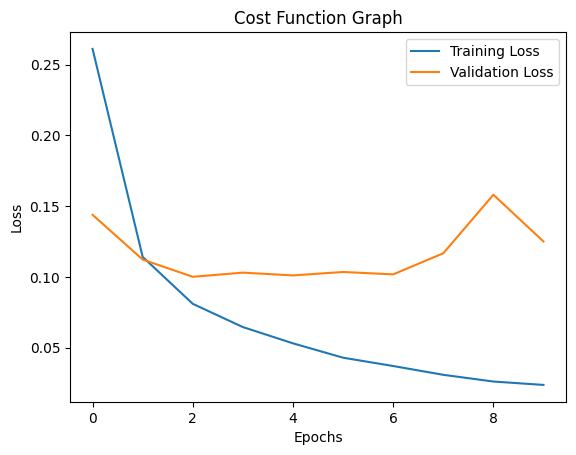

In [30]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Cost Function Graph')
plt.legend()
plt.show()

Adam (Adaptive Moment Estimation)

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [32]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
adam_optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4000 - loss: 0.8382 - val_accuracy: 0.5500 - val_loss: 0.7590
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5516 - loss: 0.7456 - val_accuracy: 0.6125 - val_loss: 0.6830
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6047 - loss: 0.6741 - val_accuracy: 0.6750 - val_loss: 0.6237
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6484 - loss: 0.6156 - val_accuracy: 0.7437 - val_loss: 0.5730
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8328 - loss: 0.5660 - val_accuracy: 0.8750 - val_loss: 0.5274
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8766 - loss: 0.5206 - val_accuracy: 0.8625 - val_loss: 0.4863
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.4784 - val_accuracy: 0.8500 - val_loss: 0.4493
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.4407 - val_accuracy: 0.8562 - val_loss

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1535  
Test Loss: 0.15352033078670502
Test Accuracy: 0.9599999785423279


Regularization & Hyperparameter Tuning

Dropout Regularization in Deep Learning

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [40]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
val_loader = DataLoader(val_set, batch_size=100, shuffle=False)
test_loader = DataLoader(test_set, batch_size=100, shuffle=False)

In [41]:
class CNN_NoDropout(nn.Module):
    def __init__(self):
        super(CNN_NoDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [42]:
class CNN_WithDropout(nn.Module):
    def __init__(self, p=0.5):
        super(CNN_WithDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=p)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [43]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs=10, device='cpu'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        model.eval()
        total, correct, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * correct / total)

        print(f"Epoch [{epoch+1}/{epochs}] Train Acc: {train_accs[-1]:.2f}% Val Acc: {val_accs[-1]:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss()

model_no = CNN_NoDropout().to(device)
opt_no = optim.SGD(model_no.parameters(), lr=0.01, momentum=0.9)
loss_no_train, loss_no_val, acc_no_train, acc_no_val = train_and_validate(
    model_no, train_loader, val_loader, opt_no, criterion, epochs, device
)

model_do = CNN_WithDropout(p=0.5).to(device)
opt_do = optim.SGD(model_do.parameters(), lr=0.01, momentum=0.9)
loss_do_train, loss_do_val, acc_do_train, acc_do_val = train_and_validate(
    model_do, train_loader, val_loader, opt_do, criterion, epochs, device
)

Epoch [1/10] Train Acc: 89.21% Val Acc: 97.47%
Epoch [2/10] Train Acc: 97.81% Val Acc: 98.01%
Epoch [3/10] Train Acc: 98.46% Val Acc: 98.27%
Epoch [4/10] Train Acc: 98.76% Val Acc: 98.62%
Epoch [5/10] Train Acc: 99.04% Val Acc: 98.70%
Epoch [6/10] Train Acc: 99.20% Val Acc: 98.69%
Epoch [7/10] Train Acc: 99.28% Val Acc: 98.85%
Epoch [8/10] Train Acc: 99.45% Val Acc: 98.97%


NameError: name 'loss_no_train' is not defined

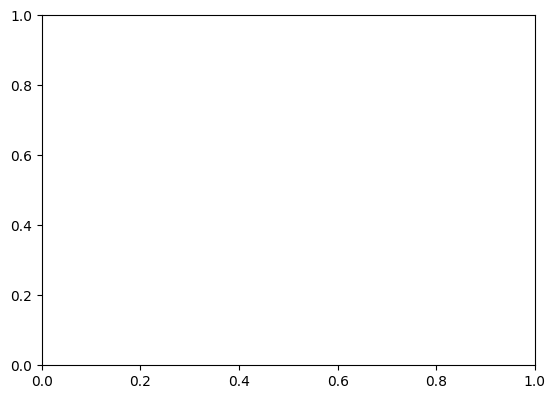

In [ ]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1); plt.plot(loss_no_train, label='No Dropout'); plt.plot(loss_do_train, label='With Dropout'); plt.title('Training Loss'); plt.legend()
plt.subplot(2,2,2); plt.plot(loss_no_val, label='No Dropout'); plt.plot(loss_do_val, label='With Dropout'); plt.title('Validation Loss'); plt.legend()
plt.subplot(2,2,3); plt.plot(acc_no_train, label='No Dropout'); plt.plot(acc_do_train, label='With Dropout'); plt.title('Training Accuracy'); plt.legend()
plt.subplot(2,2,4); plt.plot(acc_no_val, label='No Dropout'); plt.plot(acc_do_val, label='With Dropout'); plt.title('Validation Accuracy'); plt.legend()
plt.tight_layout(); plt.show()
def visualize_predictions(model, loader, title, device='cpu', n=6):
    model.to(device); model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(10,3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i].cpu().squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

visualize_predictions(model_no, test_loader, "Without Dropout", device)
visualize_predictions(model_do, test_loader, "With Dropout", device)

Batch Normalization

In [ ]:
import tensorflow as tf

# Define a simple model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_shape=(784,)),
    # Add Batch Normalization layer
    tf.keras.layers.BatchNormalization(),  
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Activation('softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32)

In [ ]:
import torch
import torch.nn as nn

# Define a simple model
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(784, 64)
        # Add Batch Normalization layer
        self.bn = nn.BatchNorm1d(64)  
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.fc1(x)
        # Apply Batch Normalization
        x = self.bn(x)  
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

# Instantiate the model
model = Model()

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
for epoch in range(5):
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

L1 & L2 Regularization

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

print("Coefficients:", lasso.coef_)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Coefficients:", ridge.coef_)

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ElasticNet(alpha=1.0, l1_ratio=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Coefficients:", model.coef_)

Hyperparameter Tuning

In [ ]:
!pip install tensorflow scikeras scikit-learn

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
def create_model(learning_rate=0.001, dropout_rate=0.5):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
model = KerasClassifier(
    model=create_model,
    verbose=0
)

param_grid = {
    "model__learning_rate": [0.001, 0.0001],
    "model__dropout_rate": [0.3, 0.5],
    "epochs": [5, 10],
    "batch_size": [32, 64]
}

In [ ]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3
)

grid_result = grid.fit(x_train, y_train)

In [ ]:
print("Best Parameters:", grid_result.best_params_)
print("Best Score:", grid_result.best_score_)

In [ ]:
best_model = grid_result.best_estimator_.model_

test_loss, test_accuracy = best_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy)

Convolutional Neural Networks

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

In [13]:
!pip install pillow

Success! Image size is: (120, 120)


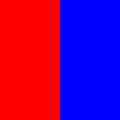

In [21]:
import os
import numpy as np
from PIL import Image

# Create a small image locally so the notebook does not depend on a missing file.
image_path = "/tmp/sample_image.jpg"
if not os.path.exists(image_path):
    image = np.zeros((120, 120, 3), dtype=np.uint8)
    image[:, :60, 0] = 255
    image[:, 60:, 2] = 255
    Image.fromarray(image).save(image_path, format="JPEG")

img = Image.open(image_path)
print(f"Success! Image size is: {img.size}")
img


Original Image Shape: (300, 300, 1)


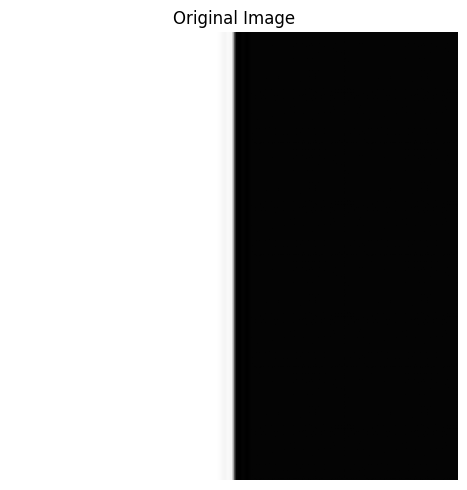

In [23]:
image_path = "/tmp/sample_image.jpg"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

In [3]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

After Convolution Shape: (1, 300, 300, 1)


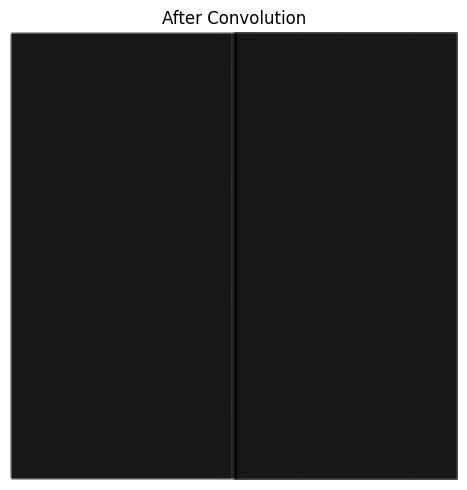

In [24]:
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

After ReLU Shape: (1, 300, 300, 1)


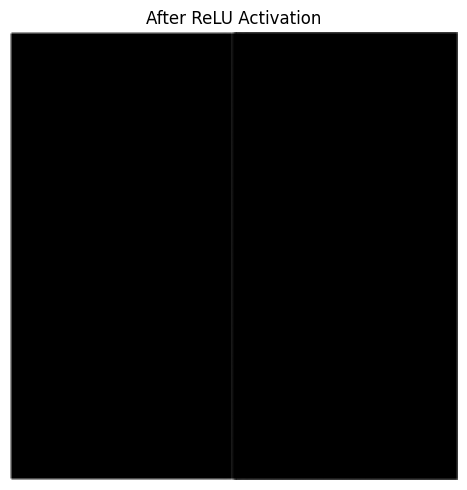

In [25]:
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

After Pooling Shape: (1, 150, 150, 1)


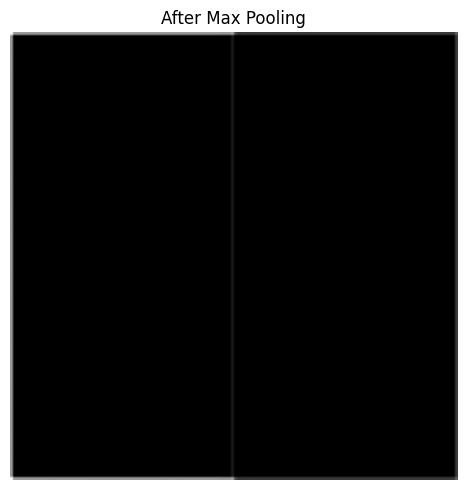

In [26]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

In [27]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[380. 228. 228. 228. 228. 228. 228. 228. 228. 228. 228. 228. 228. 228.
 228. 228. 228. 228. 228. 228.]


In [28]:
dense_layer = tf.keras.layers.Dense(
    units=64,         
    activation='relu' 
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)


Pooling Layers

In [29]:
from tensorflow.keras.layers import MaxPooling2D
import numpy as np

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
]).reshape(1, 4, 4, 1)

max_pool = MaxPooling2D(pool_size=(2, 2), strides=2)
output = max_pool(feature_map)

print(output.numpy().reshape(2, 2))

[[6 9]
 [5 8]]


In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import AveragePooling2D

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
], dtype=np.float32).reshape(1, 4, 4, 1)  

avg_pool = AveragePooling2D(pool_size=(2, 2), strides=2)
output = avg_pool(feature_map)
print(output.numpy().reshape(2, 2))

[[3.75 4.75]
 [3.5  5.75]]


In [31]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
], dtype=np.float32).reshape(1, 4, 4, 1) 

gm_pool = GlobalMaxPooling2D()
gm_output = gm_pool(feature_map)

ga_pool = GlobalAveragePooling2D()
ga_output = ga_pool(feature_map)

print("Global Max Pooling Output:", gm_output.numpy())
print("Global Average Pooling Output:", ga_output.numpy())

Global Max Pooling Output: [[9.]]
Global Average Pooling Output: [[4.4375]]


Building CNN using PyTorch

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

 56%|█████▌    | 95.0M/170M [31:43<24:56, 50.5kB/s]  

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Building CNN using TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_data=(test_images, test_labels))

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Image Classification

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

In [ ]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

In [ ]:
predictions = model.predict(x_test)

import numpy as np

# Example: predicting first test image
print("Predicted class:", np.argmax(predictions[0]))
print("Actual class:", np.argmax(y_test[0]))

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()

CNN Architectures

In [ ]:
LeNet-5

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows,cols,1) 

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [ ]:
def build_lenet(input_shape):
  # Define Sequential Model
  model = tf.keras.Sequential()

  # C1 Convolution Layer
  model.add(tf.keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh', input_shape=input_shape))

  # S2 SubSampling Layer
  model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

  # C3 Convolution Layer
  model.add(tf.keras.layers.Conv2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'))

  # S4 SubSampling Layer
  model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

  # C5 Fully Connected Layer
  model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

  # Flatten the output so that we can connect it with the fully connected layers by converting it into a 1D Array
  model.add(tf.keras.layers.Flatten())

  # FC6 Fully Connected Layers
  model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

  # Output Layer
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  return model

In [ ]:
lenet = build_lenet(input_shape)

# Compile the model
lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We will be allowing 10 itterations to happen
epochs = 10
history = lenet.fit(x_train, y_train, epochs=epochs,batch_size=128, verbose=1)

# Check Accuracy of the Model
# Transform labels to one hot encoding
if len(y_test.shape) != 2 or y_test.shape[1] != 10:
  y_test = tf.keras.utils.to_categorical(y_test, 10)

loss ,acc= lenet.evaluate(x_test, y_test)
print('Accuracy : ', acc)

x_train = x_train.reshape(x_train.shape[0], 28,28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28,28)
print('Test Data', x_test.shape, y_test.shape)

# Plot the Image
image_index = 8888
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')

# Make Prediction
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1 ))
print(pred.argmax())

AlexNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=15,
                    validation_split=0.2,
                    verbose=1)

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

ResNet (Residual Network)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
import numpy as np
import os

In [ ]:
batch_size = 32
epochs = 200
data_augmentation = True
num_classes = 10
subtract_pixel_mean = True
n = 3
version = 1  

if version == 1:
    depth = n * 6 + 2
elif version == 2:
    depth = n * 9 + 2

model_type = 'ResNet %dv%d' % (depth, version)

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
input_shape = x_train.shape[1:]


x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

if subtract_pixel_mean:
    x_train_mean = np.mean(x_train, axis=0)
    x_train -= x_train_mean
    x_test -= x_train_mean

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

In [ ]:
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 180:
        lr *= 0.5e-3
    elif epoch > 160:
        lr *= 1e-3
    elif epoch > 120:
        lr *= 1e-2
    elif epoch > 80:
        lr *= 1e-1
    print('Learning rate:', lr)
    return lr

In [ ]:
def resnet_layer(inputs,
                 num_filters=16,
                 kernel_size=3,
                 strides=1,
                 activation='relu',
                 batch_normalization=True,
                 conv_first=True):
    conv = Conv2D(num_filters,
                  kernel_size=kernel_size,
                  strides=strides,
                  padding='same',
                  kernel_initializer='he_normal',
                  kernel_regularizer=l2(1e-4))
    x = inputs
    if conv_first:
        x = conv(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
    else:
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
        x = conv(x)
    return x

In [ ]:
def resnet_v1(input_shape, depth, num_classes=10):
    if (depth - 2) % 6 != 0:
        raise ValueError('depth should be 6n + 2')

    num_filters = 16
    num_res_blocks = int((depth - 2) / 6)
    inputs = Input(shape=input_shape)
    x = resnet_layer(inputs=inputs)

    for stack in range(3):
        for res_block in range(num_res_blocks):
            strides = 1
            if stack > 0 and res_block == 0:
                strides = 2  # Downsample
            y = resnet_layer(x, num_filters=num_filters, strides=strides)
            y = resnet_layer(y, num_filters=num_filters, activation=None)
            if stack > 0 and res_block == 0:
                x = resnet_layer(x, num_filters=num_filters, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False)
            x = Add()([x, y])
            x = Activation('relu')(x)
        num_filters *= 2

    x = AveragePooling2D(pool_size=8)(x)
    y = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
def resnet_v2(input_shape, depth, num_classes=10):
    if (depth - 2) % 9 != 0:
        raise ValueError('depth should be 9n + 2')

    num_filters_in = 16
    num_res_blocks = int((depth - 2) / 9)
    inputs = Input(shape=input_shape)
    x = resnet_layer(inputs, num_filters=num_filters_in, conv_first=True)

    for stage in range(3):
        for res_block in range(num_res_blocks):
            activation = 'relu'
            batch_normalization = True
            strides = 1
            if stage == 0:
                num_filters_out = num_filters_in * 4
                if res_block == 0:
                    activation = None
                    batch_normalization = False
            else:
                num_filters_out = num_filters_in * 2
                if res_block == 0:
                    strides = 2
            y = resnet_layer(x, num_filters=num_filters_in, kernel_size=1,
                             strides=strides, activation=activation,
                             batch_normalization=batch_normalization, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_in, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_out, kernel_size=1, conv_first=False)
            if res_block == 0:
                x = resnet_layer(x, num_filters=num_filters_out, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False)
            x = Add()([x, y])
        num_filters_in = num_filters_out

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D(pool_size=8)(x)
    y = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
if version == 2:
    model = resnet_v2(input_shape=input_shape, depth=depth, num_classes=num_classes)
else:
    model = resnet_v1(input_shape=input_shape, depth=depth, num_classes=num_classes)

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=lr_schedule(0)),
              metrics=['accuracy'])
model.summary()

In [ ]:
save_dir = os.path.join(os.getcwd(), 'saved_models')
model_name = 'cifar10_%s_model.{epoch:03d}.keras' % model_type
os.makedirs(save_dir, exist_ok=True)
filepath = os.path.join(save_dir, model_name)

checkpoint = ModelCheckpoint(filepath=filepath,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True)
lr_scheduler = LearningRateScheduler(lr_schedule)
lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1), cooldown=0, patience=5, min_lr=0.5e-6)
callbacks = [checkpoint, lr_reducer, lr_scheduler]

In [ ]:
if not data_augmentation:
    print('Not using data augmentation.')
    history = model.fit(x_train, y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        validation_data=(x_test, y_test),
                        shuffle=True,
                        callbacks=callbacks)
else:
    print('Using real-time data augmentation.')
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    datagen.fit(x_train)
    history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
                        steps_per_epoch=x_train.shape[0] // batch_size,
                        epochs=epochs,
                        validation_data=(x_test, y_test),
                        callbacks=callbacks)

MobileNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np

# Load the MobileNetV2 model
model = MobileNetV2(weights='imagenet')

# Load an image for testing
img_path = '/content/simba-8618301_1280.jpg'  # Path to your test image
img = image.load_img(img_path, target_size=(224, 224))

# Preprocess the image
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Make predictions
preds = model.predict(x)
print('Predicted:', decode_predictions(preds, top=3)[0])

U-Net

In [ ]:
import tensorflow as tf

def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x

In [ ]:
def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='valid')(inputs)

    skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [ ]:
def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='valid')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='valid')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='valid', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

if __name__ == '__main__':
    model = unet_model(input_shape=(572, 572, 3), num_classes=2)
    model.summary()

In [ ]:
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image

img = Image.open('cat.png').convert('RGB')
img = img.resize((572, 572))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  

model = unet_model(input_shape=(572, 572, 3), num_classes=2)

predictions = model.predict(img_array)

pred_mask = np.squeeze(predictions, axis=0)
pred_mask = np.argmax(pred_mask, axis=-1).astype(np.uint8) * 255
pred_mask_img = Image.fromarray(pred_mask)
pred_mask_img = pred_mask_img.resize(img.size)

pred_mask_img.save('predicted_image.jpg')
pred_mask_img.show()

Recurrent Neural Networks

Introduction

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
text = "This is GeeksforGeeks a software training institute"
chars = sorted(list(set(text)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

In [ ]:
seq_length = 3
sequences = []
labels = []

for i in range(len(text) - seq_length):
    seq = text[i:i + seq_length]
    label = text[i + seq_length]
    sequences.append([char_to_index[char] for char in seq])
    labels.append(char_to_index[label])

X = np.array(sequences)
y = np.array(labels)

In [ ]:
X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [ ]:
model = Sequential()
model.add(SimpleRNN(50, input_shape=(seq_length, len(chars)), activation='relu'))
model.add(Dense(len(chars), activation='softmax'))

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_one_hot, y_one_hot, epochs=100)

In [ ]:
start_seq = "This is G"
generated_text = start_seq

for i in range(50):
    x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
    x_one_hot = tf.one_hot(x, len(chars))
    prediction = model.predict(x_one_hot)
    next_index = np.argmax(prediction)
    next_char = index_to_char[next_index]
    generated_text += next_char

print("Generated Text:")
print(generated_text)

Vanishing Gradient Problem

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
def build_model(activation, layers=20):
    model = Sequential()
    model.add(tf.keras.Input(shape=(2,)))
    model.add(Dense(32, activation=activation))

    for _ in range(layers - 1):
        model.add(Dense(32, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy'
    )
    return model

In [ ]:
sigmoid_model = build_model('sigmoid', layers=20)

sigmoid_history = sigmoid_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [ ]:
relu_model = build_model('relu', layers=20)

relu_history = relu_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(sigmoid_history.history['loss'], label='Sigmoid Activation')
plt.plot(relu_history.history['loss'], label='ReLU Activation')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Vanishing Gradient Effect')
plt.legend()
plt.grid(True)
plt.show()

Training of RNN Model

In [ ]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

import re
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv(r"C:\Users\SAURABH\Downloads\Clothing Review.csv")
data.head(7)

data = data[data['Class Name'].isnull() == False]

In [ ]:
sns.countplot(data=data, x='Class Name', palette='rainbow')
plt.xticks(rotation=90)
plt.show()

In [ ]:
plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Rating',palette="deep")

plt.subplot(1, 2, 2)
sns.countplot(data=data, x="Recommended IND", palette="deep")
plt.show()

In [ ]:
fig = px.histogram(data, marginal='box',
                   x="Age", title="Age Group",
                   color="Recommended IND",
                   nbins=65-18,
                   color_discrete_sequence=['green', 'red'])
fig.update_layout(bargap=0.2)

In [ ]:
fig = px.histogram(data,
                   x="Age",
                   marginal='box',
                   title="Age Group",
                   color="Rating",
                   nbins=65-18,
                   color_discrete_sequence
                   =['black', 'green', 'blue', 'red', 'yellow'])
fig.update_layout(bargap=0.2)

In [ ]:
def filter_score(rating):
    return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']

X = data[features]
y = data['Rating']
y = y.apply(filter_score)

In [ ]:
def toLower(data):
    if isinstance(data, float):
        return '<UNK>'
    else:
        return data.lower()

stop_words = stopwords.words("english")

def remove_stopwords(text):
    no_stop = []
    for word in text.split(' '):
        if word not in stop_words:
            no_stop.append(word)
    return " ".join(no_stop)

def remove_punctuation_func(text):
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

X['Title'] = X['Title'].apply(lambda x: lemm.lemmatize(x))
X['Review Text'] = X['Review Text'].apply(lambda x: lemm.lemmatize(x))

X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

X['Text'] = list(X['Title']+X['Review Text']+X['Class Name'])


X_train, X_test, y_train, y_test = train_test_split(
    X['Text'], y, test_size=0.25, random_state=42)

In [ ]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [ ]:
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

train_pad = pad_sequences(train_seq,
                          maxlen=40,
                          truncating="post",
                          padding="post")
test_pad = pad_sequences(test_seq,
                         maxlen=40,
                         truncating="post",
                         padding="post")

In [ ]:
from tensorflow import keras

model = keras.models.Sequential()
model.add(keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=40))
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.SimpleRNN(64))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(1, activation="sigmoid"))

model.build(input_shape=(None, 40))

model.summary()

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
              

history = model.fit(train_pad,
                    y_train,
                    epochs=5)

Bidirectional RNNs

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

features = 2000  
max_len = 50     

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=features)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, SimpleRNN, Dense

embedding_dim = 128  
hidden_units = 64    

model = Sequential()

model.add(Embedding(features, embedding_dim, input_length=max_len))

model.add(Bidirectional(SimpleRNN(hidden_units)))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
batch_size = 32
epochs = 5

model.fit(X_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(X_test, y_test))

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Test accuracy:', accuracy)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Bidirectional Long Short-Term Memory (Bi-LSTM)

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset = tfds.load('imdb_reviews', as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

batch_size = 32

train_dataset = train_dataset.shuffle(10000).batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

In [ ]:
example, label = next(iter(train_dataset))
print('Text:\n', example.numpy()[0])
print('\nLabel: ', label.numpy()[0])

In [ ]:
vectorize_layer = tf.keras.layers.TextVectorization(
    output_mode='int', output_sequence_length=100)

vectorize_layer.adapt(train_dataset.map(lambda x, y: x))

In [ ]:
model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(
        len(vectorize_layer.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.build(input_shape=(None,))


model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

model.summary()

In [ ]:
history = model.fit(
    train_dataset,
    epochs=3,
    validation_data=test_dataset,
)

In [ ]:
review = tf.constant(["This movie was amazing and engaging"])
prob = tf.sigmoid(model.predict(review))[0][0]

sentiment = "Positive" if prob >= 0.5 else "Negative"
print(f"Sentiment: {sentiment}, Probability: {prob:.2f}")

Gated Recurrent Units (GRU)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv('data.csv', parse_dates=['Date'], index_col='Date')
print(df.head())

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

In [ ]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)


time_step = 100
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(GRU(units=50))
model.add(Dense(units=1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [ ]:
model.fit(X, y, epochs=10, batch_size=32)

In [ ]:
input_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
predicted_values = model.predict(input_sequence)

In [ ]:
predicted_values = scaler.inverse_transform(predicted_values)
print(
    f"The predicted temperature for the next day is: {predicted_values[0][0]:.2f}°C")

Advanced Deep Learning Techniques

Autoencoders

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [ ]:
class SimpleAutoencoder(Model):
    def __init__(self, latent_dimensions):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),
            layers.Dense(latent_dimensions, activation='relu'),
        ])
        
        self.decoder = tf.keras.Sequential([
            layers.Dense(28 * 28, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    
    def call(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
latent_dimensions = 64
autoencoder = SimpleAutoencoder(latent_dimensions)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

In [ ]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Types of Autoencoders

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

decoded_imgs = autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu',
                                activity_regularizer=tf.keras.regularizers.l1(1e-5))(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

sparse_autoencoder = tf.keras.Model(input_img, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

sparse_autoencoder.fit(x_train_flat, x_train_flat,
                      epochs=50,
                      batch_size=256,
                      shuffle=True,
                      validation_data=(x_test_flat, x_test_flat))

decoded_imgs = sparse_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

denoising_autoencoder = tf.keras.Model(input_img, decoded)
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

noise_factor = 0.5
x_train_noisy = x_train_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_test_flat.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

denoising_autoencoder.fit(x_train_noisy, x_train_flat,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test_flat))

decoded_imgs = denoising_autoencoder.predict(x_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 16 
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

undercomplete_autoencoder = tf.keras.Model(input_img, decoded)
undercomplete_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

undercomplete_autoencoder.fit(x_train_flat, x_train_flat,
                             epochs=50,
                             batch_size=256,
                             shuffle=True,
                             validation_data=(x_test_flat, x_test_flat))

decoded_imgs = undercomplete_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

contractive_autoencoder = tf.keras.Model(input_img, decoded)

def contractive_loss(y_true, y_pred):
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    W = contractive_autoencoder.layers[1].kernel  
    dh = tf.gradients(contractive_autoencoder.layers[1].output, input_img)[0]
    contractive = tf.reduce_sum(tf.square(W)) * tf.reduce_sum(tf.square(dh))
    return mse + 1e-4 * contractive

contractive_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')  

contractive_autoencoder.fit(x_train_flat, x_train_flat,
                           epochs=50,
                           batch_size=256,
                           shuffle=True,
                           validation_data=(x_test_flat, x_test_flat))

decoded_imgs = contractive_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
input_img = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(
    16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(
    8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(
    1, (3, 3), activation='sigmoid', padding='same')(x)

conv_autoencoder = tf.keras.Model(input_img, decoded)
conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

conv_autoencoder.fit(x_train_cnn, x_train_cnn,
                     epochs=50,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test_cnn, x_test_cnn))

decoded_imgs = conv_autoencoder.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

latent_dim = 2
n = 10

encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation='relu',
                           strides=2, padding='same')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation='relu',
                           strides=2, padding='same')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)


def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(
    encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(
    64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(
    32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(
    1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='decoder')

outputs = decoder(z)


class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.keras.losses.binary_crossentropy(
            K.flatten(x), K.flatten(x_decoded)
        )
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        total_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)
        return x_decoded


outputs_with_loss = VAELossLayer()(
    [encoder_inputs, outputs, z_mean, z_log_var])

vae = tf.keras.Model(encoder_inputs, outputs_with_loss, name='vae_with_loss')

vae.compile(optimizer='adam')

vae.fit(x_train_cnn, epochs=50, batch_size=256,
        validation_data=(x_test_cnn, None))

decoded_imgs = vae.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Generative Adversarial Network (GAN)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
train_dataset = datasets.CIFAR10(root='./data',\
              train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(train_dataset, \
                                batch_size=32, shuffle=True)

In [ ]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 10

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ZeroPad2d((0, 1, 0, 1)),
        nn.BatchNorm2d(64, momentum=0.82),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128, momentum=0.82),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256, momentum=0.8),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(256 * 5 * 5, 1),
        nn.Sigmoid()
    )

    def forward(self, img):
        validity = self.model(img)
        return validity

In [ ]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters()\
                         , lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters()\
                         , lr=lr, betas=(beta1, beta2))

In [ ]:
for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):
       
        real_images = batch[0].to(device) 
       
        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)
       
        real_images = real_images.to(device)

        optimizer_D.zero_grad()
       
        z = torch.randn(real_images.size(0), latent_dim, device=device)
      
        fake_images = generator(z)

        real_loss = adversarial_loss(discriminator\
                                     (real_images), valid)
        fake_loss = adversarial_loss(discriminator\
                                     (fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
    
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
      
        gen_images = generator(z)
        
        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()
       
        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()

Diffusion Models

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

T = 200
betas = linear_beta_schedule(T)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

In [ ]:
def forward_diffusion_sample(x_0, t, noise=None):
    """
    Add noise to the image x_0 at timestep t
    """
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
    return sqrt_alphas_cumprod * x_0 + sqrt_one_minus_alphas_cumprod * noise, noise

In [ ]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
        )

    def forward(self, x, t):
        return self.net(x)

In [ ]:
def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(), 
        lambda x: x * 2 - 1 
    ])
    dataset = MNIST(root="./data", train=True, download=True, transform=transform)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
    return dataloader

def train(model, dataloader, optimizer, epochs=5):
    for epoch in range(epochs):
        for step, (x, _) in enumerate(dataloader):
            x = x.to(device)
            t = torch.randint(0, T, (x.shape[0],), device=device).long()
            x_noisy, noise = forward_diffusion_sample(x, t)
            noise_pred = model(x_noisy, t)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

In [ ]:
@torch.no_grad()
def sample(model, image_size, num_samples):
    model.eval()
    x = torch.randn((num_samples, 1, image_size, image_size), device=device)
    for t in reversed(range(T)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        pred_noise = model(x, t_tensor)
        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]
        beta = betas[t]
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0
        x = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
dataloader = get_data()

train(model, dataloader, optimizer)

samples = sample(model, 28, 16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4, normalize=True)
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

Encoder Decoder Models

In [ ]:
import numpy as np, pandas as pd, string
from string import digits
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

lines = pd.read_csv("/content/Hindi_English_Truncated_Corpus.csv", encoding='utf-8')
lines = lines[lines['source'] == 'ted'][['english_sentence', 'hindi_sentence']].dropna().drop_duplicates()
lines = lines.sample(n=25000, random_state=42)

In [ ]:
def clean_text(text):
    exclude = set(string.punctuation)
    text = ''.join(ch for ch in text if ch not in exclude)
    text = text.translate(str.maketrans('', '', digits))
    return text.strip().lower()

In [ ]:
lines['english_sentence'] = lines['english_sentence'].apply(clean_text)
lines['hindi_sentence'] = lines['hindi_sentence'].apply(clean_text)
lines['hindi_sentence'] = lines['hindi_sentence'].apply(lambda x: 'start_ ' + x + ' _end')

In [ ]:
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(lines['english_sentence'])
eng_seq = eng_tokenizer.texts_to_sequences(lines['english_sentence'])

hin_tokenizer = Tokenizer(filters='')  
hin_tokenizer.fit_on_texts(lines['hindi_sentence'])
hin_seq = hin_tokenizer.texts_to_sequences(lines['hindi_sentence'])

In [ ]:
max_eng_len = max(len(seq) for seq in eng_seq)
max_hin_len = max(len(seq) for seq in hin_seq)

encoder_input = pad_sequences(eng_seq, maxlen=max_eng_len, padding='post')
decoder_input = pad_sequences(hin_seq, maxlen=max_hin_len, padding='post')

In [ ]:
decoder_target = np.zeros((decoder_input.shape[0], decoder_input.shape[1], 1))
decoder_target[:, 0:-1, 0] = decoder_input[:, 1:]

In [ ]:
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(eng_vocab_size, latent_dim)(encoder_inputs)
enc_outputs, state_h, state_c = LSTM(latent_dim, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

In [ ]:
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(hin_vocab_size, latent_dim)
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(hin_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')
model.fit([encoder_input, decoder_input], decoder_target, batch_size=64, epochs=20, validation_split=0.2)

In [ ]:
encoder_model_inf = Model(encoder_inputs, encoder_states)

In [ ]:
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
dec_inf_emb = dec_emb_layer(decoder_inputs)
dec_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(dec_inf_emb, initial_state=decoder_states_inputs)
decoder_outputs_inf = decoder_dense(dec_outputs_inf)
decoder_model_inf = Model([decoder_inputs] + decoder_states_inputs, [decoder_outputs_inf, state_h_inf, state_c_inf])

In [ ]:
reverse_eng = {v: k for k, v in eng_tokenizer.word_index.items()}
reverse_hin = {v: k for k, v in hin_tokenizer.word_index.items()}

In [ ]:
def translate(sentence):
    sentence = clean_text(sentence)
    seq = eng_tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(seq, maxlen=max_eng_len, padding='post')
    states = encoder_model_inf.predict(padded)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = hin_tokenizer.word_index['start_']

    decoded = []
    while True:
        output, h, c = decoder_model_inf.predict([target_seq] + states)
        token_index = np.argmax(output[0, -1, :])
        word = reverse_hin.get(token_index, '')

        if word == '_end' or len(decoded) >= max_hin_len:
            break

        decoded.append(word)
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = token_index
        states = [h, c]

    return ' '.join(decoded)
    
print("English: And")
print("Hindi:", translate("And"))

Seq2Seq Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=10, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs = []

        hidden = self.encoder(src)

        input = torch.zeros(batch_size, dtype=torch.long).to(self.device)

        for t in range(max_len):
            output, hidden = self.decoder(input, hidden)
            top1 = output.argmax(1)
            outputs.append(top1.unsqueeze(0))

            if trg is not None and t < trg.shape[0] and torch.rand(1).item() < teacher_forcing_ratio:
                input = trg[t]
            else:
                input = top1

        outputs = torch.cat(outputs, dim=0)
        return outputs

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = 10
EMB_DIM = 8
HID_DIM = 16
SEQ_LEN = 5
BATCH_SIZE = 2

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

src = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)
trg = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)

outputs = model(src, trg, max_len=SEQ_LEN, teacher_forcing_ratio=0.7)

print("Source sequence (input tokens):")
print(src.T)
print("\nTarget sequence (true tokens):")
print(trg.T)
print("\nPredicted sequence (model output tokens):")
print(outputs.T)

Attention Mechanism

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Parameter(torch.rand(hidden_dim))

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[0]
        seq_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(
            self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        energy = energy.permute(0, 2, 1)
        v = self.v.repeat(batch_size, 1).unsqueeze(1)
        attention_scores = torch.bmm(v, energy).squeeze(1)
        attention_weights = F.softmax(attention_scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)
        return context, attention_weights

In [ ]:
torch.manual_seed(0)

batch_size = 1
seq_len = 4
hidden_dim = 8
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim)
decoder_hidden = torch.randn(batch_size, hidden_dim)

In [ ]:
attention = Attention(hidden_dim)
context, attn_weights = attention(decoder_hidden, encoder_outputs)

In [ ]:
print("Encoder Outputs:\n", encoder_outputs)
print("\nDecoder Hidden State:\n", decoder_hidden)
print("\nAttention Weights:\n", attn_weights)
print("\nContext Vector:\n", context)

Transfer Learning

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images]*3, axis=-1) / 255.0
test_images = np.stack([test_images]*3, axis=-1) / 255.0

train_images = tf.image.resize(tf.convert_to_tensor(train_images), [32, 32])
test_images = tf.image.resize(tf.convert_to_tensor(test_images), [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

In [ ]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)

Deep Reinforcement Learning

In [ ]:
# Import Required Libraries
import numpy as np
import tensorflow as tf
import gym

In [ ]:
# Define the DQN Model
class DQN(tf.keras.Model):
    def __init__(self, num_actions):
        super(DQN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(24, activation='relu')
        self.dense2 = tf.keras.layers.Dense(24, activation='relu')
        self.output_layer = tf.keras.layers.Dense(
            num_actions, activation='linear')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

# CartPole has 2 possible actions: push left or push right
num_actions = 2  
dqn_agent = DQN(num_actions)

In [ ]:
# Define the DQN Algorithm Parameters
learning_rate = 0.001
discount_factor = 0.99
# Initial exploration probability
exploration_prob = 1.0
# Decay rate of exploration probability
exploration_decay = 0.995
# Minimum exploration probability
min_exploration_prob = 0.1

In [ ]:
# Initialize the CartPole Environment
env = gym.make('CartPole-v1')

In [ ]:
# Define the Loss Function and Optimizer
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

In [ ]:
# Training the DQN
num_episodes = 1000
max_steps_per_episode = 500

for episode in range(num_episodes):
    state = env.reset()
    episode_reward = 0

    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy policy
        if np.random.rand() < exploration_prob:
            action = env.action_space.sample()  # Explore randomly
        else:
            action = np.argmax(dqn_agent(state[np.newaxis, :]))

        next_state, reward, done, _ = env.step(action)

        # Update the Q-values using Bellman equation
        with tf.GradientTape() as tape:
            current_q_values = dqn_agent(state[np.newaxis, :])
            next_q_values = dqn_agent(next_state[np.newaxis, :])
            max_next_q = tf.reduce_max(next_q_values, axis=-1)
            target_q_values = current_q_values.numpy()
            target_q_values[0, action] = reward + discount_factor * max_next_q * (1 - done)
            loss = loss_fn(current_q_values, target_q_values)

        gradients = tape.gradient(loss, dqn_agent.trainable_variables)
        optimizer.apply_gradients(zip(gradients, dqn_agent.trainable_variables))

        state = next_state
        episode_reward += reward

        if done:
            break

    # Decay exploration probability
    exploration_prob = max(min_exploration_prob, exploration_prob * exploration_decay)
    if (episode + 1)%100==0:
      print(f"Episode {episode + 1}: Reward = {episode_reward}")

In [ ]:
# Evaluating the Trained DQN
num_eval_episodes = 10
eval_rewards = []

for _ in range(num_eval_episodes):
    state = env.reset()
    eval_reward = 0

    for _ in range(max_steps_per_episode):
        action = np.argmax(dqn_agent(state[np.newaxis, :]))
        next_state, reward, done, _ = env.step(action)
        eval_reward += reward
        state = next_state

        if done:
            break

    eval_rewards.append(eval_reward)

average_eval_reward = np.mean(eval_rewards)
print(f"Average Evaluation Reward: {average_eval_reward}")

Reinforcement Learning

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)

In [ ]:
num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

In [ ]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])

In [ ]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        next_state = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_fire
            done = True
        elif next_state == goal:
            reward = reward_goal
            done = True
        else:
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        state = next_state
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)

In [ ]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)

In [ ]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_maze_with_path(optimal_path)

In [ ]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title('Total Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.show()


plot_rewards(rewards_all_episodes)

Deep Q-Networks (DQN)

In [ ]:
!pip install gymnasium tensorflow numpy

In [ ]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
env = gym.make("CartPole-v1")

state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print("State Size:", state_size)
print("Action Size:", action_size)

In [ ]:
model = Sequential([
    Dense(24, activation="relu", input_shape=(state_size,)),
    Dense(action_size, activation="linear")
])

model.compile(optimizer="adam", loss="mse")

In [ ]:
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.01
episodes = 50

In [ ]:
for episode in range(episodes):

    state, _ = env.reset()
    state = state.reshape(1, state_size)

    done = False

    while not done:

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(model.predict(state, verbose=0))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = next_state.reshape(1, state_size)

        target = reward
        if not done:
            target += gamma * np.max(model.predict(next_state, verbose=0))

        q_values = model.predict(state, verbose=0)
        q_values[0][action] = target

        model.fit(state, q_values, epochs=1, verbose=0)
        state = next_state

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    print(f"Episode {episode+1} completed")

In [ ]:
state, _ = env.reset()
state = state.reshape(1, state_size)

done = False
total_reward = 0

while not done:

    action = np.argmax(model.predict(state, verbose=0))

    next_state, reward, terminated, truncated, _ = env.step(action)

    total_reward += reward
    state = next_state.reshape(1, state_size)
    done = terminated or truncated

print("Total Reward:", total_reward)

Policy Gradient

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class PolicyNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(4, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x

In [ ]:
policy = PolicyNetwork()
optimizer = optim.Adam(policy.parameters(), lr=0.01)

In [ ]:
state = torch.tensor([0.5, 0.2, 0.8, 0.1], dtype=torch.float32)

In [ ]:
action_probs = policy(state)
print(action_probs)

In [ ]:
distribution = torch.distributions.Categorical(action_probs)
action = distribution.sample()
print("Selected Action:", action.item())

In [ ]:
reward = torch.tensor(2.0)
loss = -distribution.log_prob(action) * reward
print(loss)

In [ ]:
optimizer.zero_grad()
loss.backward()
optimizer.step()

REINFORCE

In [ ]:
import gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

env = gym.make('CartPole-v1')
obs_space = env.observation_space.shape[0]
act_space = env.action_space.n

In [ ]:
gamma = 0.99
learning_rate = 0.01
num_episodes = 1000
batch_size = 64

In [ ]:
class PolicyNetwork(tf.keras.Model):
    def __init__(self, hidden_units=128):
        super(PolicyNetwork, self).__init__()
        self.dense1 = layers.Dense(hidden_units, activation='relu')
        self.dense2 = layers.Dense(env.action_space.n, activation='softmax')

    def call(self, state):
        x = self.dense1(state)
        return self.dense2(x)

In [ ]:
policy = PolicyNetwork()
optimizer = tf.keras.optimizers.Adam(learning_rate)

In [ ]:
def compute_returns(rewards, gamma):
    returns = np.zeros_like(rewards, dtype=np.float32)
    running_return = 0
    for t in reversed(range(len(rewards))):
        running_return = rewards[t] + gamma * running_return
        returns[t] = running_return
    return returns

In [ ]:
def train_step(states, actions, returns):
    with tf.GradientTape() as tape:
        # Calculate the probability of each action taken
        action_probs = policy(states)
        action_indices = np.array(actions, dtype=np.int32)

        # Gather the probabilities for the actions taken
        action_log_probs = tf.math.log(tf.reduce_sum(
            action_probs * tf.one_hot(action_indices, env.action_space.n), axis=1))

        # Calculate the loss (negative log likelihood * returns)
        loss = -tf.reduce_mean(action_log_probs * returns)

    grads = tape.gradient(loss, policy.trainable_variables)
    optimizer.apply_gradients(zip(grads, policy.trainable_variables))

In [ ]:
for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    states, actions, rewards = [], [], []

    while not done:
        state_input = np.array(state, dtype=np.float32).reshape(1, -1)
        probs = policy(state_input).numpy()[0]
        action = np.random.choice(act_space, p=probs)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state_input[0])
        actions.append(action)
        rewards.append(reward)
        state = next_state

    # After episode ends
    returns = compute_returns(rewards, gamma)
    returns = (returns - np.mean(returns)) / (np.std(returns) + 1e-9)

    states_batch = np.vstack(states)
    train_step(states_batch, actions, returns)

    if episode % 100 == 0:
        print(f"Episode {episode}/{num_episodes}")

In [ ]:
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    state_input = np.array(state, dtype=np.float32).reshape(1, -1)
    probs = policy(state_input).numpy()[0]
    action = np.argmax(probs)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward
    state = next_state

print(f"Test Total Reward: {total_reward}")

Actor-Critic Methods

In [ ]:
import numpy as np
import tensorflow as tf
import gymnasium as gym

In [ ]:
# Create the CartPole Environment
env = gym.make("CartPole-v1")

In [ ]:
# Define the actor and critic networks
actor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(state_dim,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(action_dim, activation="softmax")
])

critic = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(state_dim,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

In [ ]:
actor_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
critic_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

gamma = 0.99
num_episodes = 1000

In [ ]:
for episode in range(num_episodes):

    state, _ = env.reset()
    done = False
    episode_reward = 0

    while not done:

        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)

        with tf.GradientTape() as actor_tape, tf.GradientTape() as critic_tape:

            # Actor selects action
            action_probs = actor(state_tensor)
            action = np.random.choice(action_dim, p=action_probs.numpy()[0])

            # Environment step
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state_tensor = tf.convert_to_tensor([next_state], dtype=tf.float32)

            # Critic estimates values
            state_value = critic(state_tensor)[0, 0]
            next_state_value = critic(next_state_tensor)[0, 0]

            if done:
                target = reward
            else:
                target = reward + gamma * next_state_value

            advantage = target - state_value

            # Actor Loss
            actor_loss = -tf.math.log(action_probs[0, action] + 1e-8) * tf.stop_gradient(advantage)

            # Critic Loss
            critic_loss = tf.square(advantage)

        # Update Actor
        actor_grads = actor_tape.gradient(actor_loss, actor.trainable_variables)
        actor_optimizer.apply_gradients(zip(actor_grads, actor.trainable_variables))

        # Update Critic
        critic_grads = critic_tape.gradient(critic_loss, critic.trainable_variables)
        critic_optimizer.apply_gradients(zip(critic_grads, critic.trainable_variables))

        state = next_state
        episode_reward += reward

    if episode % 10 == 0:
        print(f"Episode {episode}/{num_episodes}, Reward: {episode_reward}")

# Step 7: Test the Trained Agent

state, _ = env.reset()
done = False
total_reward = 0

while not done:

    state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)

    action_probs = actor(state_tensor)
    action = np.argmax(action_probs.numpy()[0])

    next_state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    total_reward += reward
    state = next_state

print("Test Total Reward:", total_reward)

env.close()

Proximal Policy Optimization (PPO)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from torch.utils.data import Dataset, DataLoader
import numpy as np
from collections import deque
import random

In [ ]:
class MiniPPO:
    def __init__(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = GPT2LMHeadModel.from_pretrained('gpt2')
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model.to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-5)
        self.epsilon = 0.2

In [ ]:
def train_step(self, prompt):
        self.model.train()
        inputs = self.tokenizer.encode(prompt, return_tensors='pt').to(self.device)

        outputs = self.model.generate(
            inputs,
            max_length=inputs.shape[1] + 30,
            do_sample=True,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=self.tokenizer.eos_token_id
        )

        generated_sequence = outputs.sequences[0]
        gen_tokens = generated_sequence[inputs.shape[1]:]
        text = self.tokenizer.decode(gen_tokens, skip_special_tokens=True)

        full_outputs = self.model(generated_sequence.unsqueeze(0), labels=generated_sequence.unsqueeze(0))
        logits = full_outputs.logits[:, :-1, :] 
        log_probs = torch.log_softmax(logits, dim=-1)

        current_log_probs = log_probs[0, inputs.shape[1]-1:generated_sequence.shape[0]-1].gather(1, gen_tokens.unsqueeze(-1)).squeeze(-1)

        reward = min(len(text.split()) / 25, 1.0) 
        if 'good' in text.lower() or 'great' in text.lower():
            reward += 0.5

        reward_tensor = torch.tensor([reward], device=self.device)

        loss = -(current_log_probs * reward_tensor).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return text, reward